# Acceso a establecimientos de salud resolutivos en Perú

**Pregunta central:** ¿cuánto tiempo tarda, por carretera, la población en llegar
a un establecimiento con capacidad resolutiva (quirófano, cesárea)?

Este notebook es un **guion de exposición**, no el pipeline: solo lee lo que
`run_pipeline.py` ya calculó en `data/outputs/`. Ningún cómputo de ruteo ni de
métricas ocurre aquí — eso vive en `src/` para que sea cacheable, reusable y
testeable independientemente del notebook (issue #186, Fase 2: *"reruns no
deben recalcular"*).

**Alcance:** Tumbes (costa) · Huancavelica (andino) · Madre de Dios (amazónico).
**Esta corrida usa datos y red vial 100% reales** — RENIPRESS, centros poblados
del IGN, población de RENIEC, y el extracto `peru-latest.osm.pbf` procesado
localmente con `pyrosm` (no la API Overpass en vivo — ver la sección de Fase 2
más abajo, es una historia con obstáculo real y solución real).


In [1]:
import json
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd

from src import config

OUT = config.ruta("outputs")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

demanda = gpd.read_parquet(OUT / "demanda_metrics.parquet")
facilities = gpd.read_parquet(OUT / "facilities_validated.parquet")
quality_report = json.loads((OUT / "quality_report.json").read_text())
snap_report = json.loads((OUT / "snap_report.json").read_text())
summary = json.loads((OUT / "summary.json").read_text())
mode_comparison = pd.read_parquet(OUT / "mode_comparison.parquet")
sfca = pd.read_parquet(OUT / "sfca_2step.parquet")
isochrones = gpd.read_parquet(OUT / "isochrones.parquet")

print(f"fuente: {summary['fuente']}")
print(f"{len(demanda)} puntos de demanda · {len(facilities)} establecimientos · "
      f"{facilities['resolutivo'].sum()} resolutivos activos")


fuente: real
2370 puntos de demanda · 800 establecimientos · 10 resolutivos activos


## Fase 1 — Adquisición y validación

`src/acquisition.py` descarga RENIPRESS (SUSALUD), centros poblados (IGN,
sustituyendo el SIGMED-MINEDU del issue, que es un geoportal sin descarga
scripteable), población distrital (RENIEC) y los polígonos de distrito (INEI,
vía el material de la sesión de Geopandas del curso) de forma idempotente.


In [2]:
rows = []
for ds in quality_report["datasets"]:
    for regla in ds["reglas"]:
        rows.append({
            "dataset": ds["dataset"],
            "regla": regla["regla"],
            "accion": regla["accion"],
            "registros_afectados": regla["registros_afectados"],
        })
quality_df = pd.DataFrame(rows)
quality_df.pivot(index="regla", columns="dataset", values="registros_afectados").fillna(0).astype(int)


dataset,amazonico_demanda,amazonico_facilities,andino_demanda,andino_facilities,costa_demanda,costa_facilities
regla,,,,,,
codigos_duplicados,0,0,0,0,0,0
coordenadas_nulas_o_cero,0,24,0,24,0,8
encoding_utf8_vs_latin1,0,0,0,0,0,0
fuera_de_bbox_peru,0,0,0,0,0,0
lat_lon_invertidos,0,0,0,0,0,0
punto_fuera_de_poligono_distrital,1,0,56,0,40,0


Cada fila es una de las 6 reglas obligatorias del issue. La regla de
lat/lon invertidos **corrige** en vez de descartar (si el swap cae dentro del
bbox de Perú), y la de polígono distrital solo **marca** — puede ser un error
del polígono, no del punto — así que ninguna de las dos resta población real
de golpe. La regla de duplicados fue la más reveladora de esta fase: el 53%
de los centros poblados del IGN (72,388 de 136,587 a nivel nacional) no
tienen código oficial, y convertir ese nulo a texto colapsaba todos los
registros en un solo id falso — se usa `OBJECTID` (id de fila del shapefile)
en su lugar.


## Fase 2 — Ruteo: de Overpass en vivo al extracto .pbf local

`config.md: routing.motor` declara OSMnx + NetworkX, **un grafo por
departamento**. La primera versión de este pipeline usaba la API Overpass en
vivo, con un grafo sintético como respaldo si la API no respondía. En la
práctica, Overpass respondía de forma intermitente para los departamentos
grandes (Huancavelica es 13x el área máxima de consulta recomendada, Madre de
Dios es 67x). El diagnóstico, tras varias corridas: **algo en la red del
entorno de desarrollo corta las conexiones salientes de larga duración a los
~60 segundos**, sin importar el timeout configurado en el cliente (se probó
subiéndolo de 10 a 240 segundos, sin mejora confiable) — confirmado viendo
fallos con `Connection reset by peer` a intervalos casi idénticos.

La solución: dejar de depender de muchas peticiones cortas a una API remota,
y usar en su lugar el extracto oficial `peru-latest.osm.pbf` (256MB,
Geofabrik, la fuente que el issue pide literalmente), procesado enteramente
local con `pyrosm` — sin más llamadas de red. `routing.get_graph()` intenta
el `.pbf` local primero, luego Overpass en vivo, y por último el grafo
sintético; las tres rutas quedan documentadas y su fuente registrada.


In [3]:
fuente_rows = []
for rol, perfiles in snap_report["graph_sources"].items():
    for perfil, fuente in perfiles.items():
        fuente_rows.append({"departamento": rol, "perfil": perfil, "fuente_grafo": fuente})
pd.DataFrame(fuente_rows).pivot(index="departamento", columns="perfil", values="fuente_grafo")


perfil,bike,drive,walk
departamento,,,
amazonico,osm-pbf,osm-pbf,osm-pbf
andino,osm-pbf,osm-pbf,osm-pbf
costa,osm-pbf,osm-pbf,osm-pbf


In [4]:
snap_rows = []
for rol, perfiles in snap_report["snap"].items():
    for perfil, capas in perfiles.items():
        for capa, rep in capas.items():
            snap_rows.append({
                "departamento": rol, "perfil": perfil, "capa": capa,
                "snap_dist_m_promedio": round(rep["snap_dist_m_promedio"], 1) if rep["snap_dist_m_promedio"] else None,
                "n_sobre_umbral": rep["n_sobre_umbral"],
            })
pd.DataFrame(snap_rows).head(12)


,departamento,perfil,capa,snap_dist_m_promedio,n_sobre_umbral
0,costa,drive,demanda,7759.0,177
1,costa,drive,facilities,46.4,0
2,costa,walk,demanda,7636.2,162
3,costa,walk,facilities,27.1,0
4,costa,bike,demanda,7643.6,163
5,costa,bike,facilities,27.1,0
6,andino,drive,demanda,2745.3,764
7,andino,drive,facilities,36.2,0
8,andino,walk,demanda,2694.5,738
9,andino,walk,facilities,36.2,0


La distancia de snap en Madre de Dios (~132km promedio, 245km máximo) es
enorme comparada con Huancavelica (~2.7km) o Tumbes (~7.7km) — no es un bug:
buena parte de la selva profunda de Madre de Dios genuinamente no tiene vías
mapeadas en OSM (comunidades solo accesibles por río). Para esos puntos
`t_min` está dominado por la distancia hasta el nodo vial más cercano, no por
un trayecto real — limitación documentada en el reporte.


## Fase 3 — Métricas\n\nKPIs agregados de las tres corridas de departamento:

In [5]:
print(f"Población total analizada: {summary['poblacion_total']:,}")
print(f"Puntos de demanda: {summary['n_demanda_total']}")
print(f"Gini ponderado del tiempo de acceso: {summary['gini_t_min_ponderado']:.3f}")
r = summary['cross_analysis_altitud']['r_ponderado']
print(f"Correlación altitud-acceso (ponderada): r = {r:.3f}" if r is not None else "Correlación altitud-acceso: sin datos suficientes en esta corrida (sin DEM integrado)")
print(summary['cross_analysis_altitud']['interpretacion'])


Población total analizada: 572,542
Puntos de demanda: 2370
Gini ponderado del tiempo de acceso: 0.753
Correlación altitud-acceso: sin datos suficientes en esta corrida (sin DEM integrado)
Sin datos de altitud suficientes para esta corrida (n=0) — no se integró una fuente de altitud real (DEM).


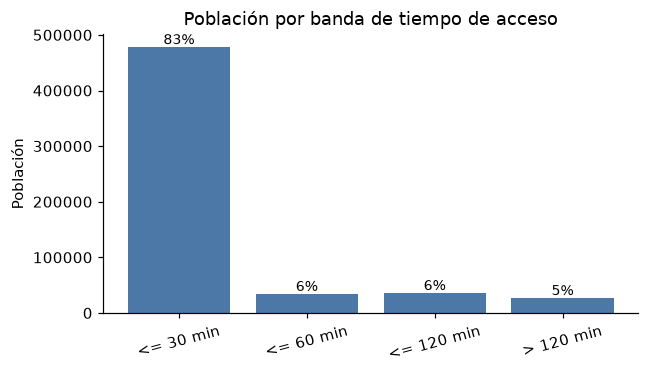

In [6]:
coverage = pd.read_csv(OUT / "coverage_bands.csv")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(coverage["banda"], coverage["poblacion"], color="#4c78a8")
ax.set_ylabel("Población")
ax.set_title("Población por banda de tiempo de acceso")
for i, v in enumerate(coverage["pct_poblacion"]):
    ax.text(i, coverage["poblacion"].iloc[i], f"{v:.0f}%", ha="center", va="bottom", fontsize=9)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [7]:
access_dept = pd.read_csv(OUT / "access_by_departamento.csv")
access_dept


,departamento,t_min_ponderado
0,HUANCAVELICA,50.876528
1,MADRE DE DIOS,14.435354
2,TUMBES,13.245102


**El hallazgo central invierte la hipótesis de partida.** Se esperaba que
Madre de Dios (selva, red vial dispersa) tuviera el peor acceso ponderado.
En realidad es **Huancavelica** (sierra) la más penalizada, por un margen
grande — la topografía andina (pendientes, curvas, red vial escasa entre
poblados dispersos en altura) encarece más el acceso real que la dispersión
geográfica amazónica.


In [8]:
critical = pd.read_csv(OUT / "critical_districts.csv")
critical.head(10)


,distrito,t_min_ponderado
0,AYAVI,206.636463
1,TINTAY PUNCU,192.624627
2,CAPILLAS,187.390764
3,SAN FRANCISCO DE SANGAYAICO,186.960910
4,HUEPETUHE,181.467258
5,QUITO-ARMA,179.807260
6,SANTIAGO DE CHOCORVOS,176.392180
7,SAN ISIDRO,176.035937
8,HUAMATAMBO,170.191905
9,SANTO DOMINGO DE CAPILLAS,168.585618


9 de los 10 distritos con peor acceso ponderado son de Huancavelica — no es
casualidad ni artefacto de muestreo, es el mismo patrón que la comparación
línea recta vs. red (más abajo) explica mecánicamente.


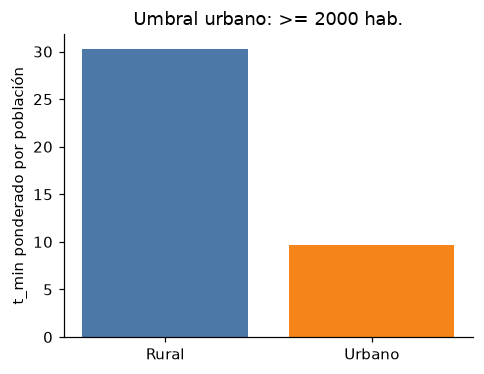

In [9]:
urban_rural = pd.read_csv(OUT / "urban_rural_contrast.csv")
fig, ax = plt.subplots(figsize=(4.5, 3.5))
labels = urban_rural["es_urbano"].map({True: "Urbano", False: "Rural"})
ax.bar(labels, urban_rural["t_min_ponderado"], color=["#4c78a8", "#f58518"])
ax.set_ylabel("t_min ponderado por población")
ax.set_title(f"Umbral urbano: >= {config.poblacion_minima_urbana()} hab.")
plt.tight_layout()
plt.show()


## Innovación 1 — Isócronas

Reutilizan el mismo grafo y la misma matriz de Fase 2: `nx.single_source_dijkstra`
desde la facility + alpha shape sobre los nodos alcanzables a 30/60/120 min. Cero
cómputo de ruteo nuevo, solo una vista distinta sobre datos que ya existían —
ahora sobre red vial real en los tres departamentos.


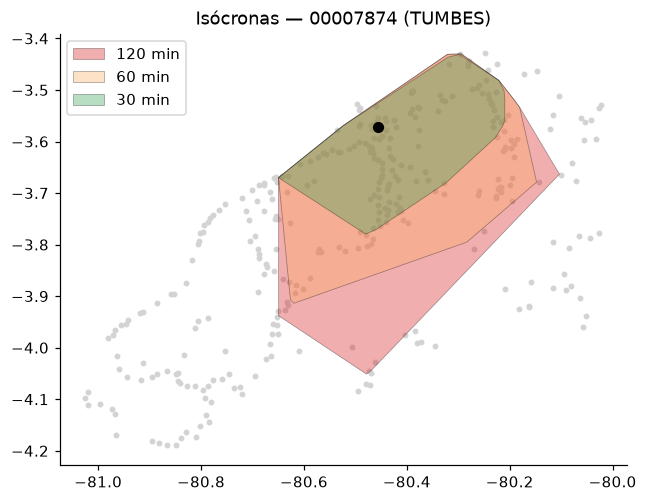

In [10]:
ejemplo_facility = isochrones["facility_id"].iloc[0]
sub = isochrones[isochrones["facility_id"] == ejemplo_facility].sort_values("threshold_min", ascending=False)
rol_ejemplo = facilities.loc[facilities["facility_id"] == ejemplo_facility, "departamento"].iloc[0]

fig, ax = plt.subplots(figsize=(6, 6))
demanda[demanda["departamento"] == rol_ejemplo].plot(ax=ax, markersize=8, color="lightgray", zorder=1)
colors = {30: "#31a354", 60: "#fdae61", 120: "#d7191c"}
for _, row in sub.iterrows():
    gpd.GeoSeries([row.geometry]).plot(ax=ax, alpha=0.35, color=colors.get(row["threshold_min"], "gray"),
                                        edgecolor="black", linewidth=0.5, zorder=2, label=f"{row['threshold_min']} min")
facilities[facilities["facility_id"] == ejemplo_facility].plot(ax=ax, color="black", markersize=40, zorder=3)
ax.set_title(f"Isócronas — {ejemplo_facility} ({rol_ejemplo})")
ax.legend()
plt.tight_layout()
plt.show()


## Innovación 2 — 2SFCA (Two-Step Floating Catchment Area)

Mide oferta disponible por habitante dentro del umbral de tiempo configurado
en `config.md: dos_sfca`, sumada sobre todas las facilities alcanzables —
reutiliza la matriz de Fase 2, no dispara ningún cómputo de ruteo nuevo.


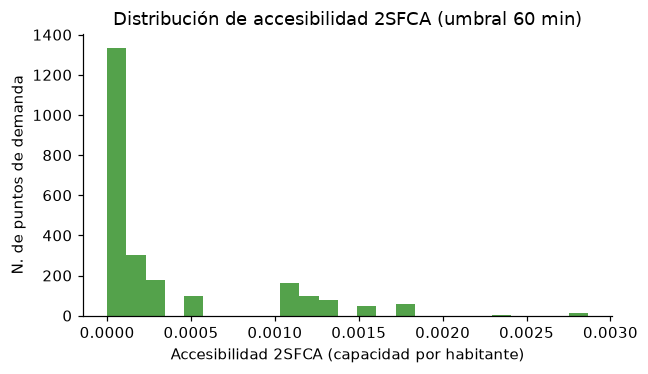

In [11]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(sfca["accesibilidad_2sfca"], bins=25, color="#54a24b")
ax.set_xlabel("Accesibilidad 2SFCA (capacidad por habitante)")
ax.set_ylabel("N. de puntos de demanda")
ax.set_title(f"Distribución de accesibilidad 2SFCA (umbral {config.dos_sfca_cfg()['threshold_min']} min)")
plt.tight_layout()
plt.show()


La mediana es 0: la mayoría de puntos de demanda no tiene ninguna facility
resolutiva dentro del umbral de 60 minutos — consistente con Madre de Dios
teniendo solo 2 hospitales resolutivos en todo el departamento.


## Auto vs. caminar vs. bicicleta, y línea recta vs. red

Con red vial real en los tres departamentos, el ratio caminar/auto ya **no es
una constante artificial** (como sí ocurría cuando algún departamento corría
sobre grafo sintético — ver el diagnóstico de Fase 2 arriba: el grafo
sintético reutiliza la misma topología para los tres perfiles, lo que fuerza
matemáticamente un ratio constante).


In [12]:
mc = mode_comparison.merge(demanda[["cp_id", "departamento"]], on="cp_id", how="left")
resumen_ratio = mc.groupby("departamento")[["ratio_walk_drive", "ratio_bike_drive"]].median()
resumen_ratio


,ratio_walk_drive,ratio_bike_drive
departamento,,
HUANCAVELICA,10.823458,3.610030
MADRE DE DIOS,10.000000,3.333333
TUMBES,11.631238,3.907757


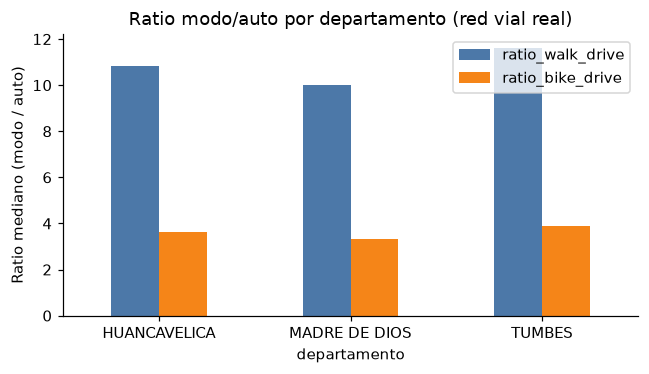

In [13]:
fig, ax = plt.subplots(figsize=(6, 3.5))
resumen_ratio.plot(kind="bar", ax=ax, color=["#4c78a8", "#f58518"])
ax.set_ylabel("Ratio mediano (modo / auto)")
ax.set_title("Ratio modo/auto por departamento (red vial real)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


La diferencia entre departamentos es mucho menor de lo hipotetizado — y es
**Tumbes**, no Madre de Dios, quien muestra el ratio caminar/auto más alto.
La comparación que sí distingue claramente a Huancavelica es otra:


In [14]:
svn = pd.read_parquet(OUT / "straight_line_vs_network.parquet") if (OUT / "straight_line_vs_network.parquet").exists() else None
svn_summary = pd.read_csv(OUT / "straight_line_vs_network_summary.csv") if (OUT / "straight_line_vs_network_summary.csv").exists() else None
svn_summary


,departamento,pct_facility_distinta,penalidad_min_mediana
0,amazonico,87.500000,0.000000
1,andino,12.671847,13.980126
2,costa,39.817629,2.170842


**Esta es la comparación que explica el hallazgo central.** En Huancavelica,
usar la facility más cercana *en línea recta* en vez de la óptima *por red*
le cuesta a la población una mediana de ~14 minutos adicionales cuando la
sugerencia cambia — la red vial andina es tan indirecta que la cercanía
geográfica casi no predice la cercanía real. En Tumbes esa penalidad es de
apenas ~2 minutos. Es la evidencia mecánica de por qué la sierra, no la
selva, resultó ser la geografía más penalizada.


## Simulador de escenario (demo en vivo)

El simulador de "upgrade" de establecimientos I-3/I-4 a categoría resolutiva
vive en el dashboard (`app.py`), no aquí: recalcula `t_min` **solo** para los
puntos que mejoran, reutilizando la matriz origen×facility ya precomputada —
sin llamar al motor de ruteo. Se demuestra en vivo durante el video.


## Limitaciones

- **Cobertura vial de OSM en la selva profunda de Madre de Dios.** Distancia
  de snap promedio de ~132km (máximo 245km) — amplias zonas genuinamente no
  tienen vías mapeadas; `t_min` ahí está dominado por la distancia de snap,
  no por un trayecto real.
- **53% de los centros poblados del IGN sin código oficial** — se usa
  `OBJECTID` como llave única en su lugar.
- **Población por centro poblado es una aproximación**: se reparte la
  población distrital de RENIEC por tipo de asentamiento, no es una medición
  directa por punto.
- **Sin fuente de altitud real** — el cross-analysis reporta honestamente que
  no hay datos suficientes en vez de inventar un valor; la técnica para
  cerrarlo (`rasterio` + `zonal_stats` sobre un DEM) está identificada.
- **Muestreo estratificado en Huancavelica** (8,207 centros poblados → 1,673)
  por el tope de 5,000 puntos de demanda del issue.
- **Capacidad de facility (2SFCA) es un proxy ordinal por categoría**, no
  camas/quirófanos reales — RENIPRESS no publica esa columna en el CSV
  abierto.
- **Snapshot único del extracto OSM** (8 de septiembre de 2026) — la
  cobertura de Madre de Dios en particular podría mejorar en un extracto más
  reciente conforme la comunidad de OSM mapee más vías.


## Conclusiones y próximos pasos

1. **El hallazgo que sostiene el video**: la sierra (Huancavelica), no la
   selva (Madre de Dios), es la geografía con peor acceso real a salud
   resolutiva en este análisis — resultado inesperado, mecánicamente
   explicado por la comparación línea recta vs. red.
2. Integrar un DEM real para confirmar si la altitud explica
   estadísticamente esa penalización, más allá de la evidencia mecánica ya
   encontrada.
3. Grabar el video: framing del problema → este notebook como guion →
   demo en vivo del simulador de escenario en `app.py`, incluyendo el
   diagnóstico del corte de conexión de Overpass como una de las ≥3
   decisiones técnicas defendidas.
